In [12]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


In [2]:
df=pd.DataFrame({
    'X1':[1,2,3,4,5,6,6,7,9,9],
    'X2':[5,3,6,8,1,9,5,8,9,2],
    'label':[1,1,0,1,0,1,0,1,0,0]
})

In [3]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

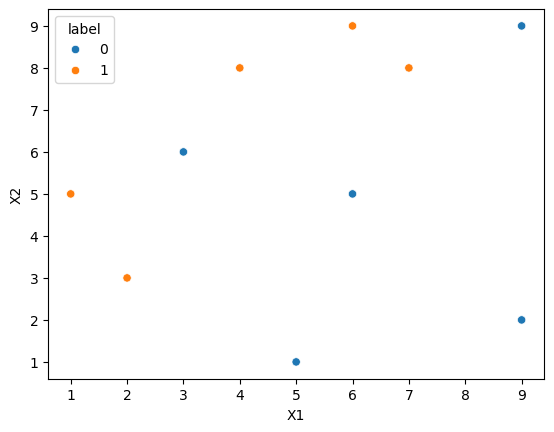

In [5]:
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [ ]:
## step 1 
df['weights']=1/df.shape[0]

In [7]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [10]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [16]:
## step 2--Train 1st model
dt1=DecisionTreeClassifier(max_depth=1)
dt1.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

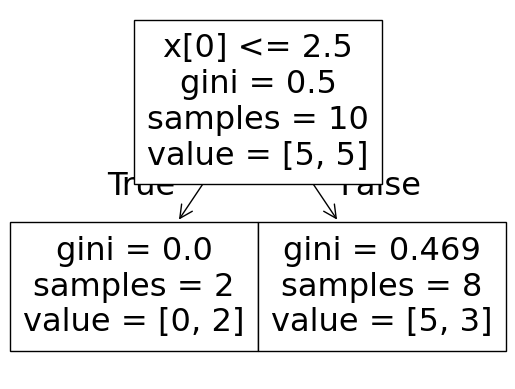

In [17]:
plot_tree(dt1)

In [18]:
df['y_pred']=dt1.predict(X)

In [19]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


<Axes: >

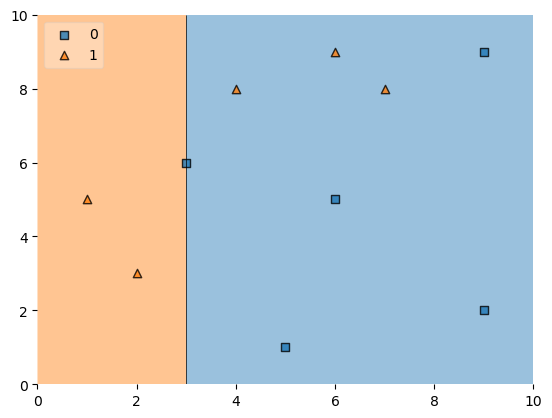

In [23]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [50]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/error+0.0000001)

In [26]:
##Step 3 --- Calculate the model weights
error = df.loc[df['label'] != df['y_pred'], 'weights'].sum()
print('error: ',error)
alpha1=calculate_model_weight(error)
print(alpha1)

error:  0.30000000000000004
0.4236489301936017


In [27]:
## step 4 ---- Update the weights

def update_row_weights(row,alpha=0.423):
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha1)
    else:
        return row['weights']*np.exp(alpha1)
    
    

In [28]:
df['Updated_weights']=df.apply(update_row_weights,axis=1)

In [29]:
df

,X1,X2,label,weights,y_pred,Updated_weights
0,1,5,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
2,3,6,0,0.1,0,0.065465
3,4,8,1,0.1,0,0.152753
4,5,1,0,0.1,0,0.065465
5,6,9,1,0.1,0,0.152753
6,6,5,0,0.1,0,0.065465
7,7,8,1,0.1,0,0.152753
8,9,9,0,0.1,0,0.065465
9,9,2,0,0.1,0,0.065465


In [30]:
df['Updated_weights'].sum()

np.float64(0.9165151389911681)

In [31]:
df['normalized_weights']=df['Updated_weights']/df['Updated_weights'].sum()

In [32]:
df['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [33]:
df

,X1,X2,label,weights,y_pred,Updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065465,0.071429
1,2,3,1,0.1,1,0.065465,0.071429
2,3,6,0,0.1,0,0.065465,0.071429
3,4,8,1,0.1,0,0.152753,0.166667
4,5,1,0,0.1,0,0.065465,0.071429
5,6,9,1,0.1,0,0.152753,0.166667
6,6,5,0,0.1,0,0.065465,0.071429
7,7,8,1,0.1,0,0.152753,0.166667
8,9,9,0,0.1,0,0.065465,0.071429
9,9,2,0,0.1,0,0.065465,0.071429


In [34]:
df['cumsum_upper']=np.cumsum(df['normalized_weights'])


In [35]:
df['cumsum_lower']=df['cumsum_upper']-df['normalized_weights']

In [36]:
df

,X1,X2,label,weights,y_pred,Updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065465,0.071429,0.071429,0.000000
1,2,3,1,0.1,1,0.065465,0.071429,0.142857,0.071429
2,3,6,0,0.1,0,0.065465,0.071429,0.214286,0.142857
3,4,8,1,0.1,0,0.152753,0.166667,0.380952,0.214286
4,5,1,0,0.1,0,0.065465,0.071429,0.452381,0.380952
5,6,9,1,0.1,0,0.152753,0.166667,0.619048,0.452381
6,6,5,0,0.1,0,0.065465,0.071429,0.690476,0.619048
7,7,8,1,0.1,0,0.152753,0.166667,0.857143,0.690476
8,9,9,0,0.1,0,0.065465,0.071429,0.928571,0.857143
9,9,2,0,0.1,0,0.065465,0.071429,1.000000,0.928571


In [39]:
def create_new_dataset(df):
    indices=[]

    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper']>a and a>row['cumsum_lower']:
                indices.append(index)
    
    return indices

In [40]:
indices_values=create_new_dataset(df)
indices_values

[2, 2, 6, 7, 9, 8, 5, 5, 4, 6]

In [41]:
second_df=df.iloc[indices_values,[0,1,2,3]]

In [42]:
second_df

,X1,X2,label,weights
2,3,6,0,0.1
2,3,6,0,0.1
6,6,5,0,0.1
7,7,8,1,0.1
9,9,2,0,0.1
8,9,9,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
4,5,1,0,0.1
6,6,5,0,0.1


In [43]:
dt2=DecisionTreeClassifier(max_depth=1)
X=second_df.iloc[:,0:2].values 
y=second_df.iloc[:,2].values

dt2.fit(X,y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.625, 0.5, '  False')]

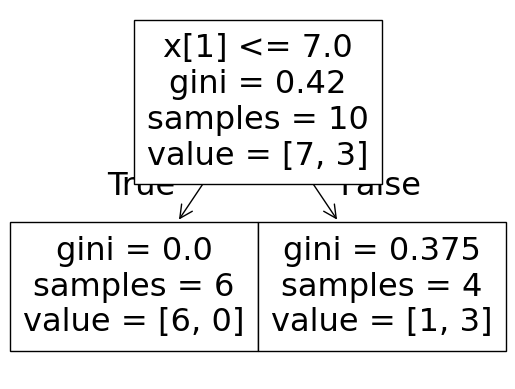

In [45]:
plot_tree(dt2)

<Axes: >

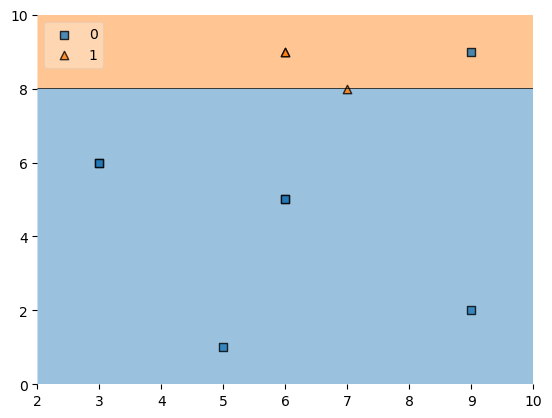

In [46]:
plot_decision_regions(X,y,clf=dt2,legend=2)

In [47]:
second_df['y_pred']=dt2.predict(X)

In [48]:
second_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,0
2,3,6,0,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,1
9,9,2,0,0.1,0
8,9,9,0,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
4,5,1,0,0.1,0
6,6,5,0,0.1,0


In [49]:
error = second_df.loc[second_df['label'] != second_df['y_pred'], 'weights'].sum()
print('error: ',error)
alpha2=calculate_model_weight(error)
print(alpha2)

error:  0.1
1.0986122886681098


In [51]:
#step 4--- update weights

def update_row_weights(row,alpha=1.09861228866):
    if row['label'] == row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [52]:
second_df['updated_weights']=second_df.apply(update_row_weights,axis=1)


In [53]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
2,3,6,0,0.1,0,0.033333
2,3,6,0,0.1,0,0.033333
6,6,5,0,0.1,0,0.033333
7,7,8,1,0.1,1,0.033333
9,9,2,0,0.1,0,0.033333
8,9,9,0,0.1,1,0.300000
5,6,9,1,0.1,1,0.033333
5,6,9,1,0.1,1,0.033333
4,5,1,0,0.1,0,0.033333
6,6,5,0,0.1,0,0.033333


In [54]:
second_df['normalized_weights']=second_df['updated_weights']/second_df['updated_weights'].sum()

In [55]:
second_df


,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
2,3,6,0,0.1,0,0.033333,0.055556
2,3,6,0,0.1,0,0.033333,0.055556
6,6,5,0,0.1,0,0.033333,0.055556
7,7,8,1,0.1,1,0.033333,0.055556
9,9,2,0,0.1,0,0.033333,0.055556
8,9,9,0,0.1,1,0.300000,0.500000
5,6,9,1,0.1,1,0.033333,0.055556
5,6,9,1,0.1,1,0.033333,0.055556
4,5,1,0,0.1,0,0.033333,0.055556
6,6,5,0,0.1,0,0.033333,0.055556


In [56]:
second_df['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [57]:
second_df['cumsum_upper']=np.cumsum(second_df['normalized_weights'])
second_df['cumsum_lower']=second_df['cumsum_upper'] - second_df['normalized_weights']

In [58]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
2,3,6,0,0.1,0,0.033333,0.055556,0.055556,0.000000
2,3,6,0,0.1,0,0.033333,0.055556,0.111111,0.055556
6,6,5,0,0.1,0,0.033333,0.055556,0.166667,0.111111
7,7,8,1,0.1,1,0.033333,0.055556,0.222222,0.166667
9,9,2,0,0.1,0,0.033333,0.055556,0.277778,0.222222
8,9,9,0,0.1,1,0.300000,0.500000,0.777778,0.277778
5,6,9,1,0.1,1,0.033333,0.055556,0.833333,0.777778
5,6,9,1,0.1,1,0.033333,0.055556,0.888889,0.833333
4,5,1,0,0.1,0,0.033333,0.055556,0.944444,0.888889
6,6,5,0,0.1,0,0.033333,0.055556,1.000000,0.944444


In [70]:
index_values=create_new_dataset(second_df)

In [71]:
index_values

[2, 4, 2, 8, 5, 8, 9, 8, 6, 8]

In [72]:
third_df=second_df.iloc[index_values,[0,1,2,3]]
third_df

,X1,X2,label,weights
6,6,5,0,0.1
9,9,2,0,0.1
6,6,5,0,0.1
4,5,1,0,0.1
8,9,9,0,0.1
4,5,1,0,0.1
6,6,5,0,0.1
4,5,1,0,0.1
5,6,9,1,0.1
4,5,1,0,0.1


In [73]:
dt3=DecisionTreeClassifier(max_depth=1)
X=third_df.iloc[:,0:2].values
y=third_df.iloc[:,2].values
dt3.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.625, 0.5, '  False')]

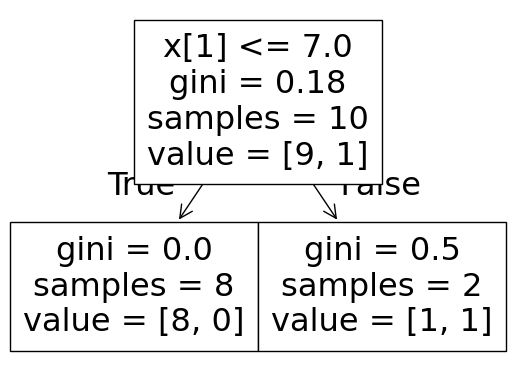

In [74]:
plot_tree(dt3)

<Axes: >

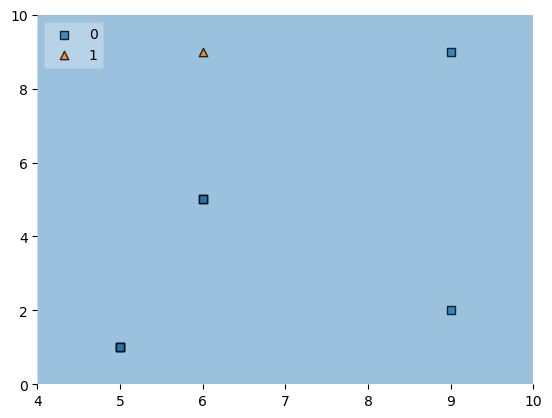

In [75]:
plot_decision_regions(X,y,clf=dt3,legend=2)

In [77]:
print(X,y)

[[6 5]
 [9 2]
 [6 5]
 [5 1]
 [9 9]
 [5 1]
 [6 5]
 [5 1]
 [6 9]
 [5 1]] [0 0 0 0 0 0 0 0 1 0]


In [78]:
third_df['y_pred']=dt3.predict(X)

In [79]:
third_df

,X1,X2,label,weights,y_pred
6,6,5,0,0.1,0
9,9,2,0,0.1,0
6,6,5,0,0.1,0
4,5,1,0,0.1,0
8,9,9,0,0.1,0
4,5,1,0,0.1,0
6,6,5,0,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
4,5,1,0,0.1,0


In [80]:
alpha3=calculate_model_weight(0.1)

In [81]:
print(alpha1,alpha2,alpha3)

0.4236489301936017 1.0986122886681098 1.0986122942236651


## Predictions

In [82]:
df

,X1,X2,label,weights,y_pred,Updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065465,0.071429,0.071429,0.000000
1,2,3,1,0.1,1,0.065465,0.071429,0.142857,0.071429
2,3,6,0,0.1,0,0.065465,0.071429,0.214286,0.142857
3,4,8,1,0.1,0,0.152753,0.166667,0.380952,0.214286
4,5,1,0,0.1,0,0.065465,0.071429,0.452381,0.380952
5,6,9,1,0.1,0,0.152753,0.166667,0.619048,0.452381
6,6,5,0,0.1,0,0.065465,0.071429,0.690476,0.619048
7,7,8,1,0.1,0,0.152753,0.166667,0.857143,0.690476
8,9,9,0,0.1,0,0.065465,0.071429,0.928571,0.857143
9,9,2,0,0.1,0,0.065465,0.071429,1.000000,0.928571


In [ ]:
## we are picking the existing row from the dataset
## 1   5    1
## 9   9    0

In [83]:
query=np.array([1,5]).reshape(1,2)

In [84]:
print(dt1.predict(query))
print(dt2.predict(query))
print(dt3.predict(query))

[1]
[0]
[0]


In [85]:
alpha1*1 + alpha2*(-1) + alpha3*(-1)

np.float64(-1.7735756526981732)

In [86]:
np.sign(-1.77)

np.float64(-1.0)

In [87]:
query=np.array([9,9]).reshape(1,2)
print(dt1.predict(query)
      ,dt2.predict(query)
      ,dt3.predict(query))

[0] [1] [0]


In [88]:
alpha1*(-1) + alpha2*(1) + alpha3*(-1)

np.float64(-0.4236489357491571)

In [89]:
np.sign(-0.42)

np.float64(-1.0)

## **In my code 1st query gives the wrong prediction and 2nd query gives the correct prediction from the adaboost algorithm method...............**